In [1]:
%env XLA_FLAGS="--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"

env: XLA_FLAGS="--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"


In [2]:
import os
print(os.environ.get("XLA_FLAGS"))

"--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"


In [3]:
# i had issues with gpu, so for now set to cpu mode

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [4]:
from __future__ import print_function
from optparse import OptionParser
import json
import os
import pdb
import sys
import time

import h5py
import joblib
import numpy as np
import pandas as pd
from scipy.stats import poisson
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
import tensorflow as tf

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

from basenji import plots
from basenji import trainer
from basenji import dataset
from basenji import rnann
%matplotlib inline
if tf.__version__[0] == '1':
  tf.compat.v1.enable_eager_execution()

2026-07-13 18:12:28.564712: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-13 18:12:28.564809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-13 18:12:28.695627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-13 18:12:29.044670: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-13 18:12:31.848382: W tensorflow/compiler/tf2

# Eval

In [5]:
base_path = '/s/project/ml4rg_students/2026/project03'
fold = f'{base_path}/datasets/deeplearning/train_gru/f0_c0'

In [6]:
fold

'/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0'

In [40]:
head_i = 1
shifts = [0]
split_label = 'test'

params_file = f"{fold}/train/params.json"
model_file = f"{fold}/train/model{head_i}_best.h5"
data_dir = f"{fold}/data{head_i}"
targets_file = f"{data_dir}/targets.txt"

In [41]:
with open(params_file) as params_open:
    params = json.load(params_open)
params_model = params['model']
params_train = params['train']

eval_data = dataset.RnaDataset(data_dir,
    split_label=split_label,
    batch_size=params_train['batch_size'],
    mode='eval'
)
print('done')
seqnn_model = rnann.RnaNN(params_model, )
print('done')
seqnn_model.restore(model_file)
print('done')
# seqnn_model.build_ensemble(shifts)
# print('done')

targets_df = pd.read_csv(targets_file, index_col=0, sep='\t')

done
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence (InputLayer)       [(None, 12288, 6)]        0         
                                                                 
 stochastic_shift_3 (Stocha  (None, 12288, 6)          0         
 sticShift)                                                      
                                                                 
 conv1d_21 (Conv1D)          (None, 12284, 64)         1920      
                                                                 
 layer_normalization_21 (La  (None, 12284, 64)         128       
 yerNormalization)                                               
                                                                 
 re_lu_27 (ReLU)             (None, 12284, 64)         0         
                                                                 
 conv1d_22 (Conv1D)          (None, 12280, 64)        

In [42]:
# default from saluki_test.py

test_loss, test_metric1, test_metric2 = seqnn_model.evaluate(eval_data)

# print summary statistics
print('\nTest Loss:         %7.5f' % test_loss)
print('Test PearsonR:     %7.5f' % test_metric1.mean())
print('Test R2:           %7.5f' % test_metric2.mean())

22/22 [==============================] - 7s 312ms/step - loss: 0.6211 - pearsonr: 0.7128 - r2: 0.4890

Test Loss:         0.62108
Test PearsonR:     0.71276
Test R2:           0.48902


## Held out eval

In [24]:
df_genes = pd.read_table(f'/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data{head_i}/genes.tsv')

In [25]:
df_genes['Split'].value_counts()

Split
train    10989
valid     1375
test      1374
Name: count, dtype: int64

In [27]:
head_i

1

In [29]:
y_pred = seqnn_model.predict(eval_data, head_i=0)

22/22 [==============================] - 7s 315ms/step


In [30]:
y_pred.shape

(1375, 1)

In [31]:
y_test = eval_data.numpy()[1]

In [32]:
y_test.shape

(1375, 1, 1)

In [33]:
y_test = y_test.squeeze()
y_pred = y_pred.squeeze()

In [34]:
from scipy.stats import pearsonr

In [35]:
def pearson(x, y):
    r = pearsonr(x, y)[0]
    return round(r, 4)

In [36]:
pearson(y_test, y_pred)

0.7285

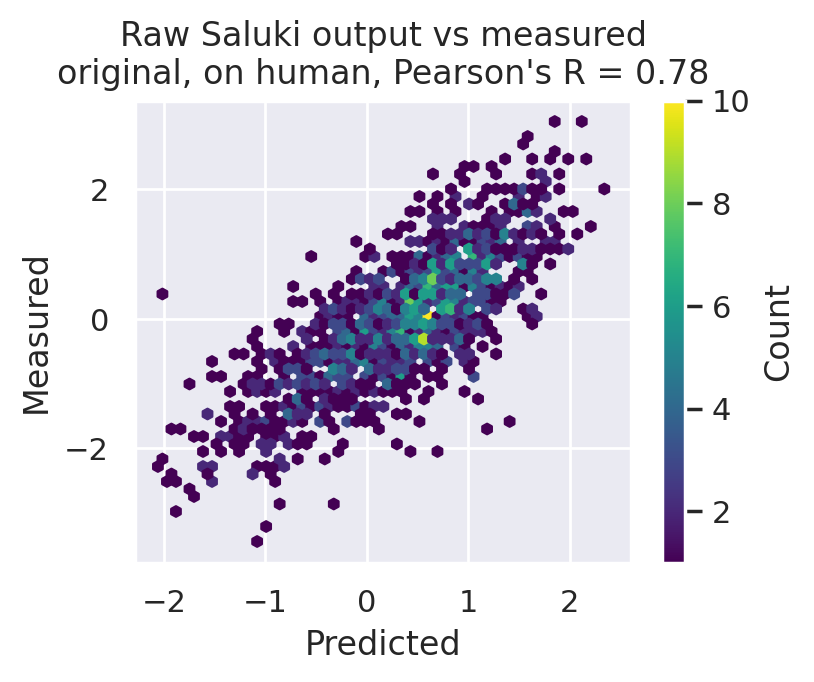

In [135]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    y_pred,
    y_test,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki output vs measured\noriginal, on human, Pearson's R = {pearson(y_test, y_pred):.2f}")
plt.show()

In [87]:
df_val_genes = df_genes[df_genes['Split'] == 'valid'].copy()

In [88]:
df_val_genes['orig_saluki_pred'] = y_pred

In [89]:
pearson(df_val_genes['Stability'], df_val_genes['orig_saluki_pred'])

0.7285

In [90]:
df_val_genes.to_csv('/s/project/ml4rg_students/2026/project03/project-half-life/results/val_genes_mouse.csv', index=False)

In [1]:
# import sys
# !{sys.executable} -m pip install pyranges --quiet

# !{sys.executable} -m pip install scikit-learn --quiet

In [2]:
import os
import pandas as pd
import numpy as np
import pyranges as pr
from tqdm import tqdm
tqdm.pandas()

In [26]:
df_vars = pd.read_parquet("/s/project/ml4rg_students/2026/project03/datasets/human/GTEx_eQTLs/GTEx_Analysis_v11_eQTL_SuSiE/Brain_Cortex.v11.eQTLs.SuSiE_summary.parquet")

In [27]:
df_vars = df_vars.rename(
    columns={
        'phenotype_id': 'gene_id',
        'pip': 'PIP'
    }
)

In [28]:
df_vars['gene_id'] = df_vars['gene_id'].progress_apply(lambda x: x.split('.')[0])

100%|██████████| 268624/268624 [00:00<00:00, 1578789.81it/s]


In [5]:
df_genes = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')

In [6]:
df_genes

,Unnamed: 0,Fold,Gene,Stability,Length,Split
0,0,0,ENSG00000000457,-1.437941,3090,test
1,1,0,ENSG00000001631,-0.184992,4762,test
2,2,0,ENSG00000002549,1.395107,2213,test
3,3,0,ENSG00000003137,-0.657063,4732,test
4,4,0,ENSG00000003987,0.064368,3850,test
...,...,...,...,...,...,...
12963,12963,9,ENSG00000273045,-0.975974,1667,train
12964,12964,9,ENSG00000274286,-0.480628,3371,train
12965,12965,9,ENSG00000275004,-1.830486,5721,train
12966,12966,9,ENSG00000275183,-1.360496,1916,train


In [7]:
gtf = pr.read_gtf("/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/datasets/human/Homo_sapiens.GRCh38.83.gtf.gz")#.as_df()

In [8]:
gtf.columns

Index(['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand',
       'Frame', 'gene_id', 'gene_version', 'gene_name', 'gene_source',
       'gene_biotype', 'havana_gene', 'havana_gene_version', 'transcript_id',
       'transcript_version', 'transcript_name', 'transcript_source',
       'transcript_biotype', 'havana_transcript', 'havana_transcript_version',
       'tag', 'transcript_support_level', 'exon_number', 'exon_id',
       'exon_version', 'ccds_id', 'protein_id', 'protein_version'],
      dtype='str')

In [10]:
df_expr = pd.read_parquet("/s/project/QNA/gtex_counts/GTEx_median_raw_counts_per_tissue.parquet")

In [11]:
df_expr['gene_id'] = df_expr['gene_id'].progress_apply(lambda x: x.split('.')[0])

100%|██████████| 56200/56200 [00:00<00:00, 1574036.83it/s]


In [12]:
df_expr = df_expr.set_index('gene_id')

In [13]:
df_expr = df_expr.drop(columns='gene_name')

In [38]:
len(var_gr)

0

In [36]:
df

""


In [34]:
var_gr_safe = var_gr.copy()

In [43]:
var_gr_safe

,gene_id,gene_name,biotype,variant_id,PIP,af,cs_id,cs_size,afc,afc_se,gene_biotype,Chromosome,Start,Ref,Alt,End
0,ENSG00000188976,NOC2L,protein_coding,chr1_817889_C_G_b38,0.111075,0.994403,1,9,0.326469,0.362557,protein_coding,chr1,817889,C,G,817890
1,ENSG00000188976,NOC2L,protein_coding,chr1_832400_G_A_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,832400,G,A,832401
2,ENSG00000188976,NOC2L,protein_coding,chr1_834695_C_T_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,834695,C,T,834696
3,ENSG00000188976,NOC2L,protein_coding,chr1_843189_A_G_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,843189,A,G,843190
4,ENSG00000188976,NOC2L,protein_coding,chr1_844647_G_T_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,844647,G,T,844648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164558,ENSG00000155961,RAB39B,protein_coding,chrX_155695384_C_T_b38,0.001846,0.276119,1,212,NaN,NaN,protein_coding,chrX,155695384,C,T,155695385
164559,ENSG00000155961,RAB39B,protein_coding,chrX_155699751_C_T_b38,0.005713,0.274254,1,212,NaN,NaN,protein_coding,chrX,155699751,C,T,155699752
164560,ENSG00000155961,RAB39B,protein_coding,chrX_155700291_CAA_C_b38,0.005713,0.274254,1,212,NaN,NaN,protein_coding,chrX,155700291,CAA,C,155700292
164561,ENSG00000155961,RAB39B,protein_coding,chrX_155708407_T_C_b38,0.002748,0.186567,1,212,NaN,NaN,protein_coding,chrX,155708407,T,C,155708408


In [44]:
cds

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,havana_transcript,havana_transcript_version,tag,transcript_support_level,exon_number,exon_id,exon_version,ccds_id,protein_id,protein_version
0,1,ensembl_havana,CDS,69090,70005,.,+,0,ENSG00000186092,4,...,OTTHUMT00000003223,2,basic,NA,1,NaN,NaN,CCDS30547,ENSP00000334393,3
1,1,ensembl,CDS,182708,182746,.,+,0,ENSG00000279928,1,...,NaN,NaN,basic,1,1,NaN,NaN,NaN,ENSP00000485457,1
2,1,ensembl,CDS,183113,183240,.,+,1,ENSG00000279928,1,...,NaN,NaN,basic,1,2,NaN,NaN,NaN,ENSP00000485457,1
3,1,ensembl,CDS,183921,184155,.,+,0,ENSG00000279928,1,...,NaN,NaN,basic,1,3,NaN,NaN,NaN,ENSP00000485457,1
4,1,havana,CDS,925941,926013,.,+,0,ENSG00000187634,10,...,OTTHUMT00000316521,2,mRNA_end_NF,3,2,NaN,NaN,NaN,ENSP00000411579,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702405,Y,ensembl,CDS,25043945,25044023,.,-,0,ENSG00000185894,8,...,NaN,NaN,basic,2,1,NaN,NaN,CCDS44030,ENSP00000480751,1
702406,Y,ensembl,CDS,25041768,25041886,.,-,0,ENSG00000185894,8,...,NaN,NaN,basic,2,2,NaN,NaN,CCDS44030,ENSP00000480751,1
702407,Y,ensembl,CDS,25038808,25038914,.,-,2,ENSG00000185894,8,...,NaN,NaN,basic,2,3,NaN,NaN,CCDS44030,ENSP00000480751,1
702408,Y,ensembl,CDS,25038100,25038116,.,-,1,ENSG00000185894,8,...,NaN,NaN,basic,2,4,NaN,NaN,CCDS44030,ENSP00000480751,1


## Compare values

In [59]:
df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')
df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

# df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data1/genes.tsv')
# df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv')

In [49]:
df_1.columns

Index(['Unnamed: 0', 'Fold', 'Gene', 'Stability', 'Length', 'Split'], dtype='object')

In [50]:
df_2 = df_2.rename(columns={'gene': 'Gene'})

In [51]:
df_j = df_1.set_index('Gene').join(
    df_2.set_index('Gene'), how='inner'
).reset_index()

In [52]:
df_val = df_j[df_j['Split'] == 'valid']

In [53]:
df_val.columns

Index(['Gene', 'Unnamed: 0', 'Fold', 'Stability', 'Length', 'Split', 'chrom',
       'start', 'end', 'strand', 'fold', 'start_cds', 'end_cds', 'block_count',
       'block_sizes', 'block_starts', 'block_count_cds', 'block_sizes_cds',
       'block_starts_cds', 'half_life', 'seq', 'frame', 'splice'],
      dtype='object')

In [54]:
np.sum(df_j['Fold'] != df_j['fold'])

0

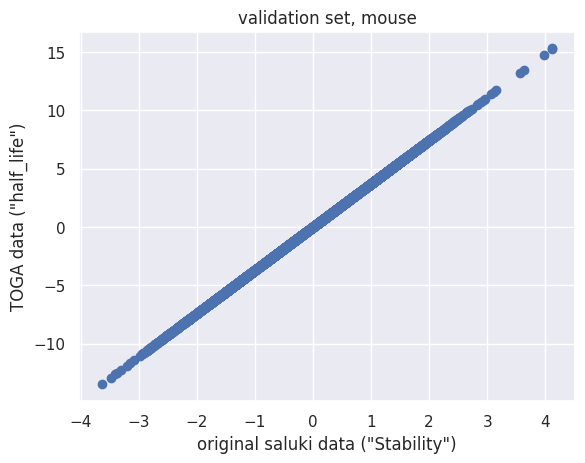

In [55]:
plt.scatter(df_j['Stability'], df_j['half_life'])
plt.xlabel('original saluki data ("Stability")')
plt.ylabel('TOGA data ("half_life")')
plt.title('validation set, mouse')
plt.show()

In [101]:
df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')
df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

# df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data1/genes.tsv')
# df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv')

In [102]:
df_2 = df_2.rename(columns={'gene': 'Gene'})

In [103]:
df_j = df_2.set_index('Gene').join(
    df_1.set_index('Gene')['Stability'], how='left'
).reset_index()

In [104]:
df_j = df_j.rename(columns={
    'half_life': 'toga_half_life',
    'Stability': 'half_life'
})

In [105]:
assert df_j[df_j['half_life'].isna()].shape[0] == 0

In [80]:
df_j.to_csv("/s/project/ml4rg_students/2026/project03/project-half-life/saluki_orig_inputs/mouse.tsv", sep='\t', index=None)

In [106]:
df_1_subset = (
    df_1.set_index("Gene")
       .loc[df_2["Gene"]]
       .reset_index()
)

In [107]:
df_1_subset

,Gene,Unnamed: 0,Fold,Stability,Length,Split
0,ENSG00000000003,7778,6,1.794249,2206,train
1,ENSG00000000457,0,0,-1.437941,3090,test
2,ENSG00000000460,1297,1,0.090046,4355,valid
3,ENSG00000000938,7779,6,-0.197011,2729,train
4,ENSG00000000971,5186,4,1.599256,4127,train
...,...,...,...,...,...,...
12761,ENSG00000278615,1296,0,0.260594,654,test
12762,ENSG00000278619,9074,6,-0.278045,1857,train
12763,ENSG00000278845,3887,2,0.384860,1705,train
12764,ENSG00000280789,11668,8,-0.501006,1702,train


In [91]:
df_1_subset.to_csv('/s/project/ml4rg_students/2026/project03/project-half-life/saluki_orig_inputs/_f0_c0/data1/genes.tsv', sep='\t', index=False)

In [108]:
df_1_subset[df_1_subset['Split'] == 'valid'].shape

(1277, 6)

# MPRA

In [14]:
with open(params_file) as params_open:
    params = json.load(params_open)
params_model = params['model']
params_train = params['train']

print('done')
seqnn_model = rnann.RnaNN(params_model)
print('done')
seqnn_model.restore(model_file, head_i)
print('done')

done
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence (InputLayer)       [(None, 12288, 6)]        0         
                                                                 
 stochastic_shift_2 (Stocha  (None, 12288, 6)          0         
 sticShift)                                                      
                                                                 
 conv1d_14 (Conv1D)          (None, 12284, 64)         1920      
                                                                 
 layer_normalization_14 (La  (None, 12284, 64)         128       
 yerNormalization)                                               
                                                                 
 re_lu_18 (ReLU)             (None, 12284, 64)         0         
                                                                 
 conv1d_15 (Conv1D)          (None, 12280, 64)        

In [15]:
from basenji import dna_io
MAXLEN = 12288

In [18]:
import sys
!{sys.executable} -m pip install tqdm --quiet

In [19]:
from tqdm import tqdm

In [9]:
mpra_data_path = '/s/project/ml4rg_students/2026/project03/saluki_paper/Fig6_S7/Siegel_testSet/'

In [10]:
df_reporter = pd.read_table(mpra_data_path+"BTV_construct.txt.gz", index_col=0, header=None, compression='gzip')
construct = df_reporter.values

df_mpras = pd.read_table(mpra_data_path+"fastUTR_mpra.txt.gz", header=None, compression='gzip')
seq = df_mpras[[0]][0].values

In [14]:
len(seq)

31054

In [20]:
aa_len = int(len(construct[1][0])/3)
coding = np.append(np.zeros(len(construct[0][0])), np.tile([1,0,0], aa_len))

reporter = construct[0]+construct[1]+construct[2]

df_perf = {
    'seq': [],
    'pred': []
}

print('%s\t%s' % ("seq", "pred"))
for i in tqdm(seq): # iterate through all sequences
    batch = np.zeros((1,MAXLEN,6))
    myseq = (reporter+i+construct[3])[0]
    batch[0,0:len(myseq),0:4] = dna_io.dna_1hot(myseq)
    batch[0,0:len(coding),4] = coding
    pred = seqnn_model.predict(batch)
    # print('%s\t%s' % (i, pred[0][0]))
    df_perf['seq'].append(i)
    df_perf['pred'].append(pred[0][0])

df_perf = pd.DataFrame(df_perf)

seq	pred


  0%|          | 0/31054 [00:00<?, ?it/s]

1/1 [==============================] - 0s 36ms/step


  0%|          | 2/31054 [00:00<43:00, 12.03it/s]

1/1 [==============================] - 0s 36ms/step


...

100%|█████████▉| 31051/31054 [49:16<00:00, 12.15it/s]

1/1 [==============================] - 0s 37ms/step


100%|█████████▉| 31053/31054 [49:17<00:00, 12.16it/s]

1/1 [==============================] - 0s 36ms/step


100%|██████████| 31054/31054 [49:17<00:00, 10.50it/s]


In [26]:
df_perf.to_csv('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/orig_saluki_Siegel_testSet_pred.csv', sep='\t', index=False)

In [25]:
df_perf.dtypes

seq      object
pred    float32
dtype: object

# Weights transfer

In [38]:
base_path = '/s/project/ml4rg_students/2026/project03'
fold = f'{base_path}/datasets/deeplearning/train_gru/f0_c0'
params_file = f"{fold}/train/params.json"
model_file = f"{fold}/train/model0_best.h5"

In [39]:
with open(params_file) as params_open:
    params = json.load(params_open)
params_model = params['model']

In [40]:
seqnn_model = rnann.RnaNN(params_model)
# print('done')
seqnn_model.restore(model_file, head_i=0)
# print('done')
# seqnn_model.load_weights(model_file)

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence (InputLayer)       [(None, 12288, 6)]        0         
                                                                 
 stochastic_shift_3 (Stocha  (None, 12288, 6)          0         
 sticShift)                                                      
                                                                 
 conv1d_21 (Conv1D)          (None, 12284, 64)         1920      
                                                                 
 layer_normalization_21 (La  (None, 12284, 64)         128       
 yerNormalization)                                               
                                                                 
 re_lu_27 (ReLU)             (None, 12284, 64)         0         
                                                                 
 conv1d_22 (Conv1D)          (None, 12280, 64)         2054

In [42]:
layer_weight_dict = dict()
for layer in seqnn_model.model.layers: 
    cfg = layer.get_config()
    weights = layer.get_weights()
    if len(weights) != 0:
        layer_weight_dict[cfg['name']] = weights

In [43]:
import pickle

In [44]:
with open("/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/project-half-life/pytorch_weights.pkl", "rb") as f:
    pytorch_weights = pickle.load(f)

In [45]:
len(pytorch_weights.keys())

20

In [16]:
# converted_pytorch_weights = {}

# for tf_weight, pytorch_weight in zip(layer_weight_dict.keys(), pytorch_weights.keys()):
#     converted_pytorch_weights[pytorch_weight] = {}
#     if pytorch_weight == 'gru':
#         w1, w2, b1, b2 = list(pytorch_weights[pytorch_weight].keys())
#         converted_pytorch_weights[pytorch_weight][w1] = np.transpose(layer_weight_dict[tf_weight][0], axes=(1, 0))
#         converted_pytorch_weights[pytorch_weight][w2] = np.transpose(layer_weight_dict[tf_weight][1], axes=(1, 0))
#         converted_pytorch_weights[pytorch_weight][b1] = layer_weight_dict[tf_weight][2][0]
#         converted_pytorch_weights[pytorch_weight][b2] = layer_weight_dict[tf_weight][2][1]
#     else:
#         for i, key in enumerate(pytorch_weights[pytorch_weight].keys()):
#             if key == 'weight' and 'conv' in pytorch_weight:
#                 converted_pytorch_weights[pytorch_weight][key] = np.transpose(layer_weight_dict[tf_weight][i], axes=(2, 1, 0))
#             elif key == 'weight' and 'output_heads' in pytorch_weight:
#                 converted_pytorch_weights[pytorch_weight][key] = np.transpose(layer_weight_dict[tf_weight][i], axes=(1, 0))
#             else:
#                 try:
#                     converted_pytorch_weights[pytorch_weight][key] = layer_weight_dict[tf_weight][i]
#                 except IndexError:
#                     assert key == 'num_batches_tracked'
#                     converted_pytorch_weights[pytorch_weight][key] = np.array(0)

In [17]:
# for converted_weight, pytorch_weight in zip(converted_pytorch_weights.keys(), pytorch_weights.keys()):
#     for i, key in enumerate(pytorch_weights[pytorch_weight].keys()):
#         print(pytorch_weights[pytorch_weight][key].shape, converted_pytorch_weights[converted_weight][key].shape)
#         assert pytorch_weights[pytorch_weight][key].shape == converted_pytorch_weights[converted_weight][key].shape

In [56]:
converted_pytorch_weights = {}

for tf_weight, pytorch_weight in zip(layer_weight_dict.keys(), pytorch_weights.keys()):
    # converted_pytorch_weights[pytorch_weight] = {}
    if pytorch_weight == 'gru':
        w1, w2, b1, b2 = list(pytorch_weights[pytorch_weight].keys())
        # converted_pytorch_weights[f"{pytorch_weight}.{w1}"] = np.transpose(layer_weight_dict[tf_weight][0], axes=(1, 0))
        # converted_pytorch_weights[f"{pytorch_weight}.{w2}"] = np.transpose(layer_weight_dict[tf_weight][1], axes=(1, 0))
        # converted_pytorch_weights[f"{pytorch_weight}.{b1}"] = layer_weight_dict[tf_weight][2][0]
        # converted_pytorch_weights[f"{pytorch_weight}.{b2}"] = layer_weight_dict[tf_weight][2][1]
        kernel = layer_weight_dict[tf_weight][0].T
        recurrent = layer_weight_dict[tf_weight][1].T
        
        H = kernel.shape[0] // 3
        
        z, r, h = np.split(kernel, 3, axis=0)
        kernel = np.concatenate([r, z, h], axis=0)
        
        z, r, h = np.split(recurrent, 3, axis=0)
        recurrent = np.concatenate([r, z, h], axis=0)
        
        converted_pytorch_weights[f"{pytorch_weight}.{w1}"] = kernel
        converted_pytorch_weights[f"{pytorch_weight}.{w2}"] = recurrent

        bias_ih = layer_weight_dict[tf_weight][2][0]
        bias_hh = layer_weight_dict[tf_weight][2][1]
        
        z, r, h = np.split(bias_ih, 3)
        bias_ih = np.concatenate([r, z, h])
        
        z, r, h = np.split(bias_hh, 3)
        bias_hh = np.concatenate([r, z, h])
        
        converted_pytorch_weights[f"{pytorch_weight}.{b1}"] = bias_ih
        converted_pytorch_weights[f"{pytorch_weight}.{b2}"] = bias_hh
    else:
        for i, key in enumerate(pytorch_weights[pytorch_weight].keys()):
            if key == 'weight' and 'conv' in pytorch_weight:
                converted_pytorch_weights[f"{pytorch_weight}.{key}"] = np.transpose(layer_weight_dict[tf_weight][i], axes=(2, 1, 0))
            elif key == 'weight' and ("dense" in pytorch_weight or "output_heads" in pytorch_weight):
                converted_pytorch_weights[f"{pytorch_weight}.{key}"] = layer_weight_dict[tf_weight][i].T
            else:
                try:
                    converted_pytorch_weights[f"{pytorch_weight}.{key}"] = layer_weight_dict[tf_weight][i]
                except IndexError:
                    assert key == 'num_batches_tracked'
                    converted_pytorch_weights[f"{pytorch_weight}.{key}"] = np.array(0)

In [57]:
converted_pytorch_weights['output_heads.0.weight'].shape

(1, 64)

In [58]:
converted_pytorch_weights['penultimate_dense.weight'].shape

(64, 64)

In [59]:
base_path = '/s/project/ml4rg_students/2026/project03'
fold = f'{base_path}/datasets/deeplearning/train_gru/f0_c0'
params_file = f"{fold}/train/params.json"
model_file = f"{fold}/train/model1_best.h5"

In [60]:
with open(params_file) as params_open:
    params = json.load(params_open)
params_model = params['model']

In [61]:
seqnn_model = rnann.RnaNN(params_model)
# print('done')
seqnn_model.restore(model_file)
# print('done')
# seqnn_model.load_weights(model_file)

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence (InputLayer)       [(None, 12288, 6)]        0         
                                                                 
 stochastic_shift_4 (Stocha  (None, 12288, 6)          0         
 sticShift)                                                      
                                                                 
 conv1d_28 (Conv1D)          (None, 12284, 64)         1920      
                                                                 
 layer_normalization_28 (La  (None, 12284, 64)         128       
 yerNormalization)                                               
                                                                 
 re_lu_36 (ReLU)             (None, 12284, 64)         0         
                                                                 
 conv1d_29 (Conv1D)          (None, 12280, 64)         2054

In [62]:
layer_weight_dict = dict()
for layer in seqnn_model.model.layers: 
    cfg = layer.get_config()
    weights = layer.get_weights()
    if len(weights) != 0:
        layer_weight_dict[cfg['name']] = weights

In [63]:
list(layer_weight_dict.keys())[-1]

'dense_9'

In [64]:
converted_pytorch_weights['output_heads.1.weight'] = layer_weight_dict[list(layer_weight_dict.keys())[-1]][0].T
converted_pytorch_weights['output_heads.1.bias'] = layer_weight_dict[list(layer_weight_dict.keys())[-1]][1]

In [65]:
with open("/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/project-half-life/pytorch_weights_converted_upd.pkl", "wb") as f:
    pickle.dump(converted_pytorch_weights, f)

In [91]:
converted_pytorch_weights_mouse = {}

for tf_weight, pytorch_weight in zip(layer_weight_dict.keys(), pytorch_weights.keys()):
    # converted_pytorch_weights_mouse[pytorch_weight] = {}
    if pytorch_weight == 'gru':
        w1, w2, b1, b2 = list(pytorch_weights[pytorch_weight].keys())
        # converted_pytorch_weights_mouse[f"{pytorch_weight}.{w1}"] = np.transpose(layer_weight_dict[tf_weight][0], axes=(1, 0))
        # converted_pytorch_weights_mouse[f"{pytorch_weight}.{w2}"] = np.transpose(layer_weight_dict[tf_weight][1], axes=(1, 0))
        # converted_pytorch_weights_mouse[f"{pytorch_weight}.{b1}"] = layer_weight_dict[tf_weight][2][0]
        # converted_pytorch_weights_mouse[f"{pytorch_weight}.{b2}"] = layer_weight_dict[tf_weight][2][1]
        kernel = layer_weight_dict[tf_weight][0].T
        recurrent = layer_weight_dict[tf_weight][1].T
        
        H = kernel.shape[0] // 3
        
        z, r, h = np.split(kernel, 3, axis=0)
        kernel = np.concatenate([r, z, h], axis=0)
        
        z, r, h = np.split(recurrent, 3, axis=0)
        recurrent = np.concatenate([r, z, h], axis=0)
        
        converted_pytorch_weights_mouse[f"{pytorch_weight}.{w1}"] = kernel
        converted_pytorch_weights_mouse[f"{pytorch_weight}.{w2}"] = recurrent

        bias_ih = layer_weight_dict[tf_weight][2][0]
        bias_hh = layer_weight_dict[tf_weight][2][1]
        
        z, r, h = np.split(bias_ih, 3)
        bias_ih = np.concatenate([r, z, h])
        
        z, r, h = np.split(bias_hh, 3)
        bias_hh = np.concatenate([r, z, h])
        
        converted_pytorch_weights_mouse[f"{pytorch_weight}.{b1}"] = bias_ih
        converted_pytorch_weights_mouse[f"{pytorch_weight}.{b2}"] = bias_hh
    else:
        for i, key in enumerate(pytorch_weights[pytorch_weight].keys()):
            if key == 'weight' and 'conv' in pytorch_weight:
                converted_pytorch_weights_mouse[f"{pytorch_weight}.{key}"] = np.transpose(layer_weight_dict[tf_weight][i], axes=(2, 1, 0))
            elif key == 'weight' and ("dense" in pytorch_weight or "output_heads" in pytorch_weight):
                converted_pytorch_weights_mouse[f"{pytorch_weight}.{key}"] = layer_weight_dict[tf_weight][i].T
            else:
                try:
                    converted_pytorch_weights_mouse[f"{pytorch_weight}.{key}"] = layer_weight_dict[tf_weight][i]
                except IndexError:
                    assert key == 'num_batches_tracked'
                    converted_pytorch_weights_mouse[f"{pytorch_weight}.{key}"] = np.array(0)

In [92]:
converted_pytorch_weights_mouse.keys()

dict_keys(['initial_conv.weight', 'middle_blocks.0.ln.weight', 'middle_blocks.0.ln.bias', 'middle_blocks.0.conv.weight', 'middle_blocks.0.conv.bias', 'middle_blocks.1.ln.weight', 'middle_blocks.1.ln.bias', 'middle_blocks.1.conv.weight', 'middle_blocks.1.conv.bias', 'middle_blocks.2.ln.weight', 'middle_blocks.2.ln.bias', 'middle_blocks.2.conv.weight', 'middle_blocks.2.conv.bias', 'middle_blocks.3.ln.weight', 'middle_blocks.3.ln.bias', 'middle_blocks.3.conv.weight', 'middle_blocks.3.conv.bias', 'middle_blocks.4.ln.weight', 'middle_blocks.4.ln.bias', 'middle_blocks.4.conv.weight', 'middle_blocks.4.conv.bias', 'middle_blocks.5.ln.weight', 'middle_blocks.5.ln.bias', 'middle_blocks.5.conv.weight', 'middle_blocks.5.conv.bias', 'gru_ln.weight', 'gru_ln.bias', 'gru.weight_ih_l0', 'gru.weight_hh_l0', 'gru.bias_ih_l0', 'gru.bias_hh_l0', 'penultimate_bn.weight', 'penultimate_bn.bias', 'penultimate_bn.running_mean', 'penultimate_bn.running_var', 'penultimate_bn.num_batches_tracked', 'penultimate_de

In [93]:
converted_pytorch_weights.keys()

dict_keys(['initial_conv.weight', 'middle_blocks.0.ln.weight', 'middle_blocks.0.ln.bias', 'middle_blocks.0.conv.weight', 'middle_blocks.0.conv.bias', 'middle_blocks.1.ln.weight', 'middle_blocks.1.ln.bias', 'middle_blocks.1.conv.weight', 'middle_blocks.1.conv.bias', 'middle_blocks.2.ln.weight', 'middle_blocks.2.ln.bias', 'middle_blocks.2.conv.weight', 'middle_blocks.2.conv.bias', 'middle_blocks.3.ln.weight', 'middle_blocks.3.ln.bias', 'middle_blocks.3.conv.weight', 'middle_blocks.3.conv.bias', 'middle_blocks.4.ln.weight', 'middle_blocks.4.ln.bias', 'middle_blocks.4.conv.weight', 'middle_blocks.4.conv.bias', 'middle_blocks.5.ln.weight', 'middle_blocks.5.ln.bias', 'middle_blocks.5.conv.weight', 'middle_blocks.5.conv.bias', 'gru_ln.weight', 'gru_ln.bias', 'gru.weight_ih_l0', 'gru.weight_hh_l0', 'gru.bias_ih_l0', 'gru.bias_hh_l0', 'penultimate_bn.weight', 'penultimate_bn.bias', 'penultimate_bn.running_mean', 'penultimate_bn.running_var', 'penultimate_bn.num_batches_tracked', 'penultimate_de

In [99]:
for key in converted_pytorch_weights.keys():
    if 'output_heads' in key:
        continue
    print(key, np.allclose(converted_pytorch_weights[key], converted_pytorch_weights_mouse[key], atol=1e-3))

initial_conv.weight False
middle_blocks.0.ln.weight False
middle_blocks.0.ln.bias False
middle_blocks.0.conv.weight False
middle_blocks.0.conv.bias False
middle_blocks.1.ln.weight False
middle_blocks.1.ln.bias False
middle_blocks.1.conv.weight False
middle_blocks.1.conv.bias False
middle_blocks.2.ln.weight False
middle_blocks.2.ln.bias False
middle_blocks.2.conv.weight False
middle_blocks.2.conv.bias False
middle_blocks.3.ln.weight False
middle_blocks.3.ln.bias False
middle_blocks.3.conv.weight False
middle_blocks.3.conv.bias False
middle_blocks.4.ln.weight False
middle_blocks.4.ln.bias False
middle_blocks.4.conv.weight False
middle_blocks.4.conv.bias False
middle_blocks.5.ln.weight False
middle_blocks.5.ln.bias False
middle_blocks.5.conv.weight False
middle_blocks.5.conv.bias False
gru_ln.weight False
gru_ln.bias False
gru.weight_ih_l0 False
gru.weight_hh_l0 False
gru.bias_ih_l0 False
gru.bias_hh_l0 False
penultimate_bn.weight False
penultimate_bn.bias False
penultimate_bn.running_mea